# Step 1: Dataset Overview

In this section, we load the dataset and inspect its structure.

In [1]:
import pandas as pd

df = pd.read_csv('data/Dataset.csv')

df.shape

(9551, 21)

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [5]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### Observation

1. We found that there are 9551 entries and 21 columns in this dataset.
2. There are multiple types of data in each column. Some are numeric datatype and some are string type.
3. Each entry has its distinct unique id ('Restaurant Id').
4. The target variable which will be used for further observations is 'Aggregate rating'.


# Step 2: Target Variable Analysis

We analyze the distribution of the Aggregate Rating column.

In [2]:
df['Aggregate rating'].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

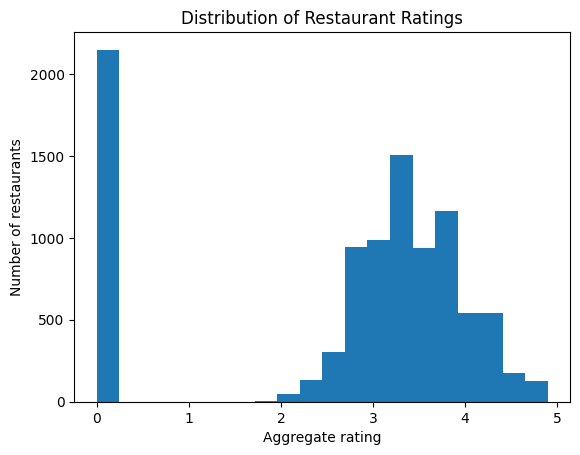

In [2]:
import matplotlib.pyplot as plt

plt.hist(df['Aggregate rating'], bins = 20)
plt.xlabel('Aggregate rating')
plt.ylabel('Number of restaurants')
plt.title('Distribution of Restaurant Ratings')
plt.show()

In [4]:
df[df['Aggregate rating'] == 0]['Votes'].describe()

count    2148.000000
mean        0.870112
std         1.048600
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max         3.000000
Name: Votes, dtype: float64

# Step 3: Removing Unrated Restaurants

Restaurants with Aggregate rating = 0 are removed because they represent unrated entries.

In [5]:
df = df[df['Aggregate rating'] > 0]

df.shape

(7403, 21)

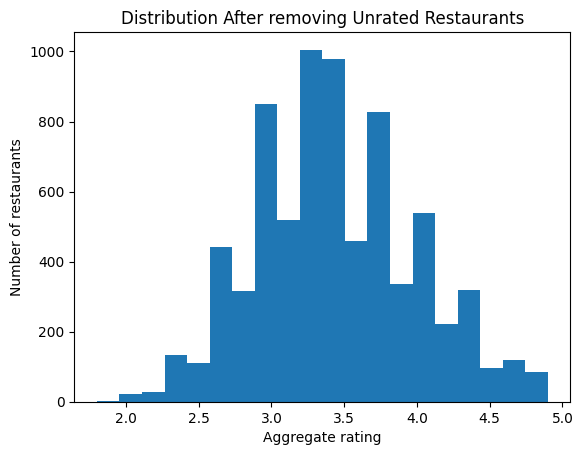

In [6]:
plt.hist(df['Aggregate rating'], bins = 20)
plt.xlabel('Aggregate rating')
plt.ylabel('Number of restaurants')
plt.title('Distribution After removing Unrated Restaurants')
plt.show()

### Observation

1. On observing the target variable, we found that there were multiple entries where the aggregate rating was 0.
2. To make the target variable accurate, we removed the entries where aggregate rating is 0.
3. After removing the entries, the plot showed a proper distribution.

In [7]:
df.corr(numeric_only = True)

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
Restaurant ID,1.000000,0.255215,-0.280596,-0.017232,0.011218,-0.006848,0.193038,-0.082984
Country Code,0.255215,1.000000,-0.736241,0.010346,0.039305,0.210459,0.412917,0.127652
Longitude,-0.280596,-0.736241,1.000000,-0.097542,0.049345,-0.074384,-0.291458,-0.085230
Latitude,-0.017232,0.010346,-0.097542,1.000000,-0.124947,-0.221437,-0.179917,-0.038285
Average Cost for two,0.011218,0.039305,0.049345,-0.124947,1.000000,0.070638,0.076790,0.063424
Price range,-0.006848,0.210459,-0.074384,-0.221437,0.070638,1.000000,0.403169,0.274103
Aggregate rating,0.193038,0.412917,-0.291458,-0.179917,0.076790,0.403169,1.000000,0.409018
Votes,-0.082984,0.127652,-0.085230,-0.038285,0.063424,0.274103,0.409018,1.000000


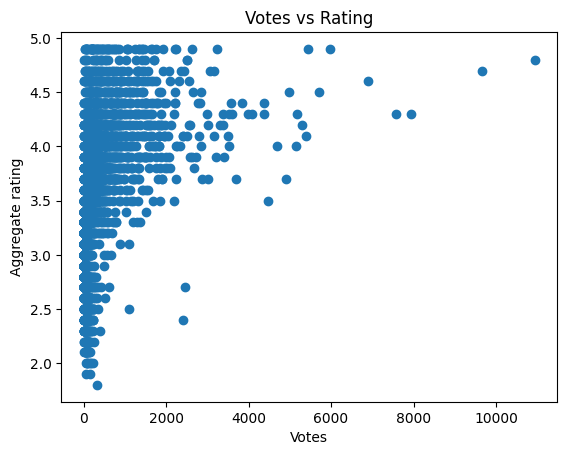

In [8]:
plt.scatter(df['Votes'], df['Aggregate rating'])
plt.xlabel('Votes')
plt.ylabel('Aggregate rating')
plt.title('Votes vs Rating')
plt.show()

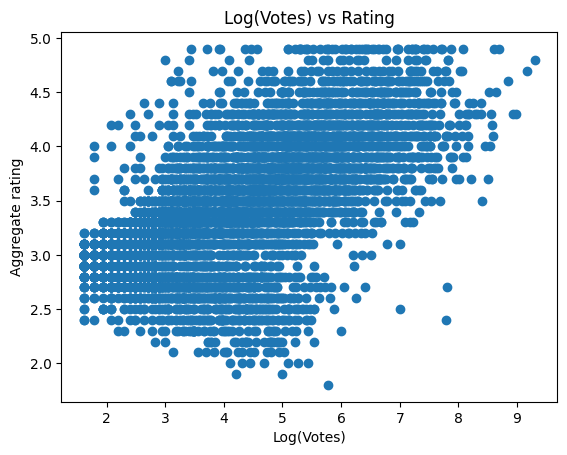

In [9]:
import numpy as np

plt.scatter(np.log1p(df['Votes']), df['Aggregate rating'])
plt.xlabel('Log(Votes)')
plt.ylabel('Aggregate rating')
plt.title('Log(Votes) vs Rating')
plt.show()

In [3]:
df.groupby('Price range')['Aggregate rating'].mean()

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64

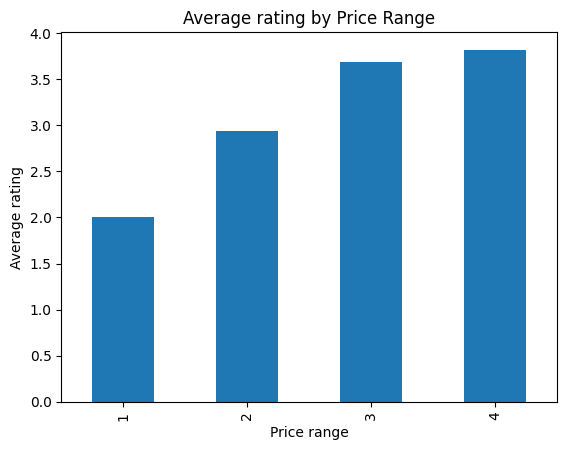

In [5]:
import matplotlib.pyplot as plt

df.groupby('Price range')['Aggregate rating'].mean().plot(kind='bar')
plt.ylabel('Average rating')
plt.title('Average rating by Price Range')
plt.show()

### Observation

1. There is a positive relationship between price range and average rating.
2. Higher price range tends to have slightly higher ratings.
3. However, price alone cannot be the sole reason for higher ratings.

In [4]:
df.groupby('Price range')['Votes'].mean()

Price range
1     44.597435
2    147.607131
3    443.860795
4    368.595563
Name: Votes, dtype: float64

In [3]:
df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64

In [4]:
city_stats = df.groupby('City').agg({
    'Aggregate rating': 'mean',
     'Restaurant ID': 'count'
})

city_stats.columns = ['Average rating', 'Restaurant count']

city_stats.sort_values(by='Restaurant count', ascending=False).head(10)

,Average rating,Restaurant count
City,,
New Delhi,2.438845,5473
Gurgaon,2.651431,1118
Noida,2.036204,1080
Faridabad,1.866932,251
Ghaziabad,2.852000,25
Bhubaneshwar,3.980952,21
Lucknow,4.195238,21
Guwahati,4.190476,21
Ahmedabad,4.161905,21


### Observation

1. Cities with a large number of restaurants tends to have more moderate average ratings.
2. Cities with fewer restaurants often show higher average ratings, likely due to smaller sample size.
3. This indicates that location influences ratings, but there is a more complex relationship and it is influenced by restaurant density and customer satisfaction.

In [5]:
df['Cuisines'].value_counts().head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

### Observation

1. The cuisine column contains both single and multiple cuisine entries.
2. Value count treats each combination as a unique category.
3. This creates high cardinality and requires preprocessing before modeling.

In [6]:
df['Cuisines'].nunique()

1825